# PROJEKT : <span style="margin-left:40px;"> Jerzy Marcin Urbański</span>

##### TEMAT:
## Analiza Jakości Powietrza Dla Wybranych Lokalizacji Oraz Okresów

Importy Bibliotek wraz z ich opisem 

<hr style="border: none; border-top: 11px dotted green;">

Sekcja bibliotek

<hr style="border: none; border-top: 11px dashed black;">

<hr style="
height:6px;
border:none;
background: linear-gradient(to right, red, orange, yellow, green, blue, purple);
">

In [1]:
# ### pandas

# Biblioteka do pracy z danymi tabelarycznymi (DataFrame), umożliwia łatwe filtrowanie, grupowanie i przekształcanie danych. 
# Używana głównie do analizy danych, czyszczenia danych oraz wczytywania/zapisywania plików (CSV, Excel, SQL).
import pandas as pd

# ### numpy
# Podstawowa biblioteka do obliczeń numerycznych w Pythonie, oferująca wydajne operacje na tablicach wielowymiarowych. 
# Wykorzystywana do obliczeń matematycznych, statystycznych oraz jako fundament dla innych bibliotek analitycznych.
import numpy as np

# ### os
# Biblioteka standardowa do interakcji z systemem operacyjnym, umożliwia pracę z plikami i katalogami oraz zmiennymi środowiskowymi. 
#Używana m.in. do automatyzacji operacji na plikach i zarządzania ścieżkami.
import os

# ### matplotlib
# Biblioteka do tworzenia wykresów i wizualizacji danych w Pythonie. Pozwala generować różne typy wykresów (liniowe, słupkowe, histogramy) 
# oraz dostosowywać ich wygląd.
import matplotlib.pyplot as plt

# ### seaborn
# Rozszerzenie matplotlib, które upraszcza tworzenie estetycznych i statystycznych wizualizacji danych. 
# Umożliwia szybkie generowanie wykresów takich jak heatmapy, wykresy rozkładu czy zależności między zmiennymi.
import seaborn as sns

# ### ydata_profiling
# Biblioteka do automatycznej analizy eksploracyjnej danych (EDA), generująca szczegółowe raporty o zbiorze danych. 
# Pokazuje statystyki, brakujące wartości, korelacje i potencjalne problemy w danych.
from ydata_profiling import ProfileReport

# ### IPython.display
# Moduł umożliwiający wyświetlanie różnych typów treści w notebookach (HTML, obrazy, wideo). 
#  Używany do wzbogacania prezentacji wyników analiz i tworzenia interaktywnych raportów.
from IPython.display import IFrame

# Moduł do obsługi ścieżek plików
from pathlib import Path

# Moduł do obliczania macirzy korelacji miedzy zmiennymi DataFrame , zarówno numerycznymi jak i kategorycznymi 
from phik import phik_matrix

Sekcja bibliotek ML

In [2]:
# import....

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

from sklearn.dummy import DummyRegressor



from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor 
# pip install xgboost lightgbm
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor



<hr style="
height:20px;
border:none;
background: linear-gradient(to right, red, orange, yellow, green, blue, purple);
">

## STEP 1. DANE SUROWE - Wczytanie + przygotowanie.
        [ LOAD DATA + PREPROCESSING NA WSTĘPNYCH DANYCH ]
Import danych z plików csv , ostateczne sprawdznie oraz potrzebna agregacja do ostatecznej wersji.

### 1.1. Dane pogodowe - weather_[..].csv


In [282]:
# import wszyskich plików do odpowiednich zmiennych 

w_pz_2021 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/weather_pz_2021.csv')
w_pz_2022 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/weather_pz_2022.csv')
w_pz_2023 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/weather_pz_2023.csv')
w_pz_2024 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/weather_pz_2024.csv')

In [ ]:
# szybkie sprawdznie 

# display(w_pz_2021.head(2))
# display(w_pz_2022.head(2))
# display(w_pz_2023.head(2))
# display(w_pz_2024.head(2))

#### 1.1.1. Połaczenie w jedne DataFrame

In [285]:
w_df = pd.concat([w_pz_2021,w_pz_2022,w_pz_2023,w_pz_2024], axis=0 , ignore_index=True)

#### 1.1.2. - Agregacja danych do postaci uniwersalnego DataFrame 

In [287]:
# przypisanie odpowiedniego id miasta [city] wg współrzędnych

w_df['city'] = w_df['longitude'].map({17.0 : 'PZ'})

In [288]:
# Selekscja kolumn do usunięcia 

# print(w_pz_2021['step'].nunique()) # kolumna ma jeden wynik -> usunać
# print('-'*140)
# print(w_pz_2022['surface'].nunique()) # kolumna ma jeden wynik -> usunać
# print('-'*140)
# print(w_pz_202[w_ld_2004["time"] != w_ld_2004["valid_time"]]) # kolumna 'valid_time' powtrza wartosci 'time' -> usunać 
# print('-'*140)
# print(w_ld_2012['number'].nunique())

In [289]:
# usunięcie niepotrzebnych kolumn ['Unnamed: 0','latitude','longitude','step','surface','valid_time']

w_df = w_df.drop(['Unnamed: 0','latitude','longitude','step','surface','valid_time','number'], axis=1)

In [290]:
# Zamiana typu danych object z kolumny 'time' na date_time

w_df['time'] = pd.to_datetime(w_df['time'])

Obliczenie prędkości wiatru ze zmiennych u10 & v10 ze wzoru tj z równania pitagorasa
- zmienna u10 => prędkość wiatru zachodniego 
- zmienna v10 => prędkość wiartu północnego 

$$
v_w = \sqrt{u_{10}^2 + v_{10}^2}
$$


In [292]:
# przeliczenie prędkości wiatru 'v_w' i dodanie jako nowa kolumna z tymi wartościami

w_df['v_w'] = np.sqrt(w_df['u10']**2 + w_df['v10']**2)

In [293]:
# ułożenie kolejnosci kolumn [info data | zmienne pogodowe] 

col_order = ['city','time','u10', 'v10','v_w','t2m','blh','sp','tcc']
w_df = w_df[col_order]

#### 1.1.3. PODSUMOWANIE PKT. 1.1 DANE POGOWE 
OPIS ZMIENNYCH 
- 'city' -> MIASTO ZAPISANE W SYMOBOLEM
    - PZ = Poznań
    - LD = Łódź 
- 'time'............ DATA GODZINA
- 'u10' -> predkosc wiatru z kierunku / jednostko = [ m/s ] 
- 'v10' -> prędkość wiatru z kierunku / jednostka = [ m/s ]
- 'v_w' -> rzeczywista prędkość wiatru / jednostka = [ m/s ]
- 't2m' -> temperatura powietrze 2m nad poziomem powierzchni / jednostka [ Kelwin ]
- 'blh' -> WYSOKOŚĆ WARSTWY GRANICZNEJ / jednostka [ m ]
- 'sp' -> CIŚNIENIE / jednostka [ Pa ]
- 'tcc' -> CAŁKOWITE ZACHMURZENIE / jednostk [ 0-1 ] [ % ]

    

### 1.2. TABELE CAŁKOWITE OPADY - total_precipition

#### 1.2.1. Import wszyskich plików do odpowiednich zmiennych 

In [297]:
tp_pz_2021 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/total_precipitation_pz_2021.csv')
tp_pz_2022 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/total_precipitation_pz_2022.csv')
tp_pz_2023 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/total_precipitation_pz_2023.csv')
tp_pz_2024 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/total_precipitation_pz_2024.csv')

In [298]:
# szybkie sprawdznie 

# print(tp_pz_2021.info())
# print('^'*140)
# display(tp_pz_2021.head(10))
# display(tp_pz_2022.head(2))
# display(tp_pz_2023.head(2))
# display(tp_pz_2024.head(2))

####  1.2.2. Połaczenie wszystkich Data Frame w jeden pogodowy 

In [300]:
tp_df = pd.concat([tp_pz_2021,tp_pz_2022,tp_pz_2023,tp_pz_2024], axis=0 , ignore_index=True).reset_index()

#### 1.2.3. - Agregacja danych do postaci uniwersalnego DataFrame 

In [302]:
# usuwamy zbedne kolumny, nie potrzebne do analizy i dalszej agregacji 

tp_df = tp_df.drop(['Unnamed: 0','time','step','number','surface','index'], axis=1) 

In [303]:
# Zamiana kolumn z data i czasem na typ danych date_time

tp_df['valid_time'] =  tp_df['valid_time'].apply(pd.to_datetime)

# Usuwamy niepotrzebne punkty pomiarowe z innych godzin 'valid_time' niż 00:00, 06:00, 12:00, 18:00 każdego dnia

tp_df = tp_df[tp_df['valid_time'].dt.hour.isin([0, 6, 12, 18])]

# zamieniamy nazwę valid_time na time , aby pasowała do poprzedniego DataFrame dane pogodowe i mozliwosci ich połaczenia

tp_df = tp_df.rename(columns={'valid_time':'time'})

In [304]:
# sprawedzenie wartosci longitude dla wybranych miast 
tp_df['longitude'].unique()

array([17.])

In [305]:
# przypisanie skrótu miasta w nowej kolumnie 'city' + usuniecie niepotrzebnej kolu

tp_df['city'] = tp_df['longitude'].map({17.0 : 'PZ'})

In [306]:
# usuwamy zbedne kolumny lognitude i 

tp_df = tp_df.drop(['longitude','latitude'], axis=1) 

#### 1.2.4. PODSUMOWANIE PKT. 1.2. CAŁKOWITE OPADY  
OPIS ZMIENNYCH 
- 'PZ' -> MIASTO ZAPISANE W SYMOBOLEM
    - PZ = Poznań
    - LD = Łódź
- 'time'............ DATA GODZINA
- 'tp' -> CAŁKOWITE OPADY / jednostka [ m ] - skumulowany opad 

### 1.3. TABELE INWERSJE - inwesrsja [..].csv

#### 1.3.1. Import wszystich plikow do odpowiednich zmienych 

In [310]:
i_pz_2021 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/inwersja_pz_2021.csv')
i_pz_2022 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/inwersja_pz_2022.csv')
i_pz_2023 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/inwersja_pz_2023.csv')
i_pz_2024 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/inwersja_pz_2024.csv')

In [311]:
# szybkie sprawdzenie 

# print(i_pz_2021.info())
# print('^'*140)
# display(i_pz_2021.head(2))
# display(i_pz_2022.head(2))
# display(i_pz_2023.loc[i_pz_2023['time']=='2023-04-23 18:00:00'])
# display(i_pz_2024.head(2))

#### 1.3.2. Łaczymy wszyskie tabele do jednego DataFrame

In [313]:
i_df = pd.concat([i_pz_2021, i_pz_2022, i_pz_2023, i_pz_2024],  axis=0, ignore_index=True)

#### 1.3.3. Agregacja danych do postaci uniwersalnego datasetu.

In [315]:
# przypisanie skrótu miasta w nowej kolumnie 'city' + usuniecie niepotrzebnej kolu

i_df['city'] = i_df['longitude'].map({17.0 : 'PZ'})

In [316]:
# Zamiana typu danych kolumny 'time' na date_time

i_df['time'] = pd.to_datetime(i_df['time'])

In [317]:
## USTALENIE INWERSJI 0/1 NA PODSTAWIE RÓŻNICY TEMPERATURY NA WYSOKOŚĆI Z CIŚNIENEIM 1000 A 925

# Rozdzielam na dwa DataFrame 
df_925 = i_df[i_df['isobaricInhPa'] == 925][['time','t','city']].rename(columns = {'t': 't_925'})
df_1000 = i_df[i_df['isobaricInhPa'] == 1000][['time','t','city']].rename(columns = {'t': 't_1000'})

# Łaczymy oba df, w jeden do obliczenia różnicy
i_df_delta = pd.merge(df_925, df_1000, how='left', on=['time','city'])

# kolumna t_delta = podaje rożnice w stopniach 
i_df_delta['t_delta'] = i_df_delta['t_1000']-i_df_delta['t_925']
i_df_delta['inversion_0/1'] = [1 if e > 0 else 0 for e in i_df_delta['t_delta']]

i_df_delta.head()

,time,t_925,city,t_1000,t_delta,inversion_0/1
0,2021-01-01 00:00:00,272.81152,PZ,272.07275,-0.73877,0
1,2021-01-01 06:00:00,273.99268,PZ,270.65967,-3.33301,0
2,2021-01-01 12:00:00,272.74536,PZ,271.50880,-1.23656,0
3,2021-01-01 18:00:00,271.33813,PZ,273.27295,1.93482,1
4,2021-01-02 00:00:00,271.29980,PZ,273.73926,2.43946,1


In [318]:
# usuwamy nie potrzebne kolumny do dalszej analizy 

i_df_delta = i_df_delta.drop(['t_925','t_1000','t_delta'],axis=1)

In [319]:
# Sprawdzenie poprawnosci inwersja_DataFrame gotowego do megre do głwnego DataFrame

display(i_df_delta.iloc[1000:1010])
print('^' * 140) 
display(i_df_delta['city'].unique())
display(i_df_delta['inversion_0/1'].unique())
print('^' * 140) 
display(i_df_delta.info())

,time,city,inversion_0/1
1000,2021-09-08 00:00:00,PZ,1
1001,2021-09-08 06:00:00,PZ,1
1002,2021-09-08 12:00:00,PZ,1
1003,2021-09-08 18:00:00,PZ,1
1004,2021-09-09 00:00:00,PZ,1
1005,2021-09-09 06:00:00,PZ,0
1006,2021-09-09 12:00:00,PZ,1
1007,2021-09-09 18:00:00,PZ,1
1008,2021-09-10 00:00:00,PZ,0
1009,2021-09-10 06:00:00,PZ,0


^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


array(['PZ'], dtype=object)

array([0, 1])

^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5844 entries, 0 to 5843
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   time           5844 non-null   datetime64[ns]
 1   city           5844 non-null   object        
 2   inversion_0/1  5844 non-null   int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 137.1+ KB


None

#### 1.3.4. PODSUMOWANIE PKT. 1.3. Inwersje
OPIS ZMIENNYCH 
- 'PZ' -> MIASTO ZAPISANE W SYMOBOLEM
    - PZ = Poznań
    - LD = Łódź
- 'time'............ DATA GODZINA
- 'inverion_0/1' -> inwersja_0 = NIE MA / inwerja_1 = JEST

### 1.4. Dane Zanieczyszczeń Powietrza - [data_polution_2023 , data_polution_2024]

#### 1.4.1. Import datasetów. 

In [323]:
polution_2021 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/data_polution_2021')
polution_2022 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/data_polution_2022')
polution_2023 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/data_polution_2023')
polution_2024 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/data_polution_2024')
# SZYBKIE SPRAWDZENIE 
display(polution_2021.head(1))
display(polution_2022.head(1))
display(polution_2023.head(1))
display(polution_2024.head(1))

,Unnamed: 0,Date_time,LdLodz_PM10,WpPozn_PM10,LdLodz_PM25,WpPozn_PM25,LdLodz_NO2,WpPozn_NO2,LdLodz_CO,WpPozn_CO
0,0,2021-01-01 01:00:00,44.0,NaN,28.0,NaN,NaN,NaN,0.401,0.55772


,Unnamed: 0,Date_time,LdLodz_PM10,WpPozn_PM10,LdLodz_PM25,WpPozn_PM25,LdLodz_NO2,WpPozn_NO2,LdLodz_CO,WpPozn_CO
0,0,2022-01-01 01:00:00,34.0,10.584,30.0,7.2631,NaN,NaN,0.431,0.10616


,Unnamed: 0,Date_time,LdLodz_PM10,WpPozn_PM10,LdLodz_PM25,WpPozn_PM25,LdLodz_NO2,WpPozn_NO2,LdLodz_CO,WpPozn_CO
0,0,2023-01-01 01:00:00,25.0,9.87387,21.384,8.16218,7.9,4.27716,0.394,0.32176


,Unnamed: 0,Date_time,LdLodz_PM10,WpPozn_PM10,LdLodz_PM25,WpPozn_PM25,LdLodz_NO2,WpPozn_NO2,LdLodz_CO,WpPozn_CO
0,0,2024-01-01 01:00:00,48.0,72.3,43.2,67.9,NaN,NaN,0.682,0.621


#### 1.4.2. Połaczenie obu datasetów do jednego DataFrame

In [325]:
# Połczenie obu lat w jeden chronologiczny dataset

polution_df = pd.concat([polution_2021,polution_2022,polution_2023, polution_2024],  axis=0, ignore_index=True)

#### 1.4.3. Agregeacja danych do postaci uniwersalnego DataFrame

In [327]:
# usuwamy zbedne kolumny, nie potrzebne do analizy i dalszej agregacji 

polution_df = polution_df.drop(['Unnamed: 0'], axis=1) 

In [328]:
# Zmiana typu danych kolumny 'Date_time' ze str na date_time 

polution_df['Date_time'] = pd.to_datetime(polution_df['Date_time'])

# Zamiania nazwy kolumny Date_time na 'time', aby dopasować do pozostałych kolumn z 'time'

polution_df = polution_df.rename(columns={'Date_time' : 'time'})

In [329]:
# Usunięcnie nie potrzebnych godzin pomiaru w ciagu każdej doby, pozostawiamy tylko 
# 00:00 ; 06:00 ; 12:00 ; 18:00

polution_df = polution_df[polution_df['time'].dt.hour.isin([0, 6, 12, 18])]

In [330]:
# Reset indexu dla polution_df

polution_df = polution_df.reset_index(drop=True)

In [331]:
polution_df.head(2)

,time,LdLodz_PM10,WpPozn_PM10,LdLodz_PM25,WpPozn_PM25,LdLodz_NO2,WpPozn_NO2,LdLodz_CO,WpPozn_CO
0,2021-01-01 06:00:00,31.0,NaN,19.0,NaN,10.4,13.9916,0.354,0.35462
1,2021-01-01 12:00:00,24.0,NaN,15.0,NaN,13.2,18.1778,0.373,0.35767


In [332]:
# Rozbijamyu polution_df na dwa DataFramy , dane Łódź oraz dane Poznań.

# Tworzy liste kolum dla wskazania wartosci dotyczaczych Łodzi -> Ld oraz Poznania -> PZ
# ld_cols = [col for col in polution_df.columns if col.startswith("Ld")]
wp_cols = [col for col in polution_df.columns if col.startswith("Wp")]

In [333]:
# Tworzymy oddzielne df dla zanieczyszczeń w Łodzi oraz Poznaniu.

# ld_polution_df = polution_df[['time'] + ld_cols].copy()
pz_polution_df = polution_df[['time'] + wp_cols].copy()

In [334]:
# Usuwamy nazwy stacji dla poszczególnych zanieczyszczeń Dla obu polution_df

# ld_polution_df.columns = ["time"] + [
#     col.replace("LdLodzCzerni_", "")
#        .replace("LdLodzJanPaw_", "") 
#     for col in ld_cols
# ]

pz_polution_df.columns = ["time"] + [
    col.replace("WpPozn_", "")
    for col in wp_cols
]
# -----------------------------------------------------------
# Dodajemy kolumne 'city' = 'LD' i 'PZ' 

# ld_polution_df['city'] = 'LD'
pz_polution_df['city'] = 'PZ'

In [335]:
pz_polution_df

,time,PM10,PM25,NO2,CO,city
0,2021-01-01 06:00:00,NaN,NaN,13.9916,0.35462,PZ
1,2021-01-01 12:00:00,NaN,NaN,18.1778,0.35767,PZ
2,2021-01-01 18:00:00,NaN,NaN,27.4239,0.41556,PZ
3,2021-01-02 00:00:00,NaN,NaN,20.7627,0.57434,PZ
4,2021-01-02 06:00:00,NaN,NaN,12.0419,0.31160,PZ
...,...,...,...,...,...,...
5839,2024-12-31 00:00:00,24.2,23.0,15.9000,0.58000,PZ
5840,2024-12-31 06:00:00,18.7,17.5,10.4000,0.51600,PZ
5841,2024-12-31 12:00:00,14.2,13.0,11.5000,0.46400,PZ
5842,2024-12-31 18:00:00,29.2,26.8,27.5000,0.89200,PZ


In [336]:
# Łaczymy oba pz i ld polution_df jednen pod drugim metoda concat()

# polution_agg_df = pd.concat([ld_polution_df, pz_polution_df])

In [337]:
# szybkie sprawdzenie 

pz_polution_df.info()
display(pz_polution_df.head(2))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5844 entries, 0 to 5843
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    5844 non-null   datetime64[ns]
 1   PM10    5606 non-null   float64       
 2   PM25    5606 non-null   float64       
 3   NO2     5669 non-null   float64       
 4   CO      5762 non-null   float64       
 5   city    5844 non-null   object        
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 274.1+ KB


,time,PM10,PM25,NO2,CO,city
0,2021-01-01 06:00:00,NaN,NaN,13.9916,0.35462,PZ
1,2021-01-01 12:00:00,NaN,NaN,18.1778,0.35767,PZ


### 1.4.4. Podsumowanie dla Danych Zanieczyszczeń = target.
OPIS ZMIENNYCH 
- PM10 -
    - OPIS: (Particulate Matter 10) to pył zawieszony składający się z cząstek o średnicy aerodynamicznej mniejszej niż 10 mikrometrów (µm).
    - JESNOSTKA: µg/m³
- PM25
    - OPIS: PM2.5 to bardzo drobny pył zawieszony o średnicy poniżej 2,5 µm.
    - JESNOSTKA: µg/m³
- NO2 - Dwutlenek azotu
    - OPIS: NO₂ to gaz należący do grupy tlenków azotu..
    - JESNOSTKA: µg/m³
- NO2 - telenek węgla
    - OPIS: CO to bezbarwny i bezwonny gaz powstający przy niecałkowitym spalaniu paliw.
    - JESNOSTKA: mg/m³

In [356]:
pz_polution_df.duplicated().sum()

0

<hr style="
height:20px;
border:none;
background: linear-gradient(to right, red, orange, yellow, green, blue, purple);
">

# STEP II

## 2. Główny DataFrame - main_df + EDA

### 2.1. Merge dane pogodowych, danych całkowitych opadów oraz danych zanieczyszczeń do jednego DataFrame
DANE_POGODOWE + DANE_CAŁKOWITYCH OPADÓW + INWERSJA => all_weather_df
ALL_WEATHER + POLUTION => MAIN_DF

In [361]:
# Łaczymy wszyskie DataFrame pogodowe do jednej all_weather_df

all_weather_df = w_df.merge(tp_df, on = ['time','city'], how = 'left').merge(i_df_delta, on = ['time','city'], how = 'left')

In [362]:
# # Szybkie sprawdzenie . 
# all_weather_df.head(2)

In [363]:
pz_main_df = all_weather_df.merge(pz_polution_df, on=['city','time'], how = 'left')

In [364]:
# # Szybkie sprawdzenie . 
# main_df.head(2)

### 2.2. Agregacja Main_df,

In [366]:
# Usunicie zbędnych kolumn u10, 'v10' jako składowe wiatru nie potrzebne do dalszych analiz.

pz_main_df = pz_main_df.drop(['u10','v10'], axis=1)

In [367]:
# Rozbijamy 'time' na szczegóły, przypisanie do nowych kolumn wartosći - Rok / Miesiac / Dzień / Dzień_tyg / 

pz_main_df = pz_main_df.assign(
    month=pz_main_df['time'].dt.month_name(),
    year=pz_main_df['time'].dt.year,
    day=pz_main_df['time'].dt.day,
    hour=pz_main_df['time'].dt.time,
    day_of_week=pz_main_df['time'].dt.day_name())


In [368]:
# Po transformacji 'time' na osobne kolumny ta, zmienna nie jest już potrzbena , wiec ja usuwamy.

pz_main_df = pz_main_df.drop('time',axis=1)

In [369]:
# Transformacja kolumna 'hour' z datetime na string

pz_main_df['hour'] = pz_main_df['hour'].astype(str)

In [370]:
# Usunięcie braków w Target

### 2.4. Walidacja main_df

In [372]:
# display(pz_main_df.info())
# print('='*140)
# display(pz_main_df.describe())
# print('='*140)
display(pz_main_df.shape)
# print('='*140)
display(pz_main_df.head(3))

(5850, 17)

,city,v_w,t2m,blh,sp,tcc,tp,inversion_0/1,PM10,PM25,NO2,CO,month,year,day,hour,day_of_week
0,PZ,3.187178,270.71216,147.41356,99757.560,0.931488,4.768372e-07,0,NaN,NaN,NaN,NaN,January,2021,1,00:00:00,Friday
1,PZ,3.497952,270.98218,250.48758,99785.560,1.000000,2.765655e-05,0,NaN,NaN,13.9916,0.35462,January,2021,1,06:00:00,Friday
2,PZ,3.090875,271.01196,346.94922,99814.125,1.000000,1.859665e-05,0,NaN,NaN,18.1778,0.35767,January,2021,1,12:00:00,Friday


<hr style="
height:20px;
border:none;
background: linear-gradient(to right, blue, purple);
">

### 2.3. EDA 

In [375]:
# # Wprowadzamy podział na dane numeryczne i zmienne kategoryczne 
# num_col = pz_main_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
# cat_col = pz_main_df.select_dtypes(include=['object']).columns.tolist()

# # Wprowadzamy podział na cechy i cele modelów predykcyjnych .

# # Lista kolumn cech i celów
# target_col = ['PM10','PM25','NO2','CO']
# feature_col = [c for c in pz_main_df.columns if c not in target_col and c not in cat_col and c != 'time']


# # Data Frame dla cech i celów 
# target_df = pz_main_df[target_col]
# feature_df = pz_main_df.drop(columns=target_col, axis=1)

# --------------------------- TESTOWE ZMIANY NA ZAKRESIE __TARGET_COL I __FEATURE_COL -----------------------------------------------

# Wprowadzamy podział na dane numeryczne i zmienne kategoryczne 
num_col = pz_main_df.select_dtypes(include=['int64', 'float64','int32']).columns.tolist()
cat_col = pz_main_df.select_dtypes(include=['object']).columns.tolist()

# Wprowadzamy podział na cechy i cele modelów predykcyjnych .

# Lista kolumn cech i celów
target_col = ['PM10','PM25','NO2','CO']
num_feature_col = [c for c in pz_main_df.columns if c not in target_col and c not in cat_col and c != 'time' and c != 'tp' and c != 'tcc' and c != 'sp']
cat_feature_col = [c for c in pz_main_df.columns if c not in target_col and c not in num_col and c != 'time']

# Data Frame dla cech i celów 
target_df = pz_main_df[target_col]
feature_df = pz_main_df[cat_feature_col+num_feature_col]



#### 2.3.1. Generujemy Raport EDA

In [377]:
# Raport zapisujemy w html dla czytelniejszej analizy (możliwy również do wyświetlenia przy uruchomieniu ostatniej 

# profile = ProfileReport(pz_main_df, title="PROJEKT_MAIN — Profiling report", explorative=True)
# report_path = Path("eda_report/projekt_main_1_profiling_report.html")
# profile.to_file(report_path) # dopisanie to_file i wygenerowanie w nowym pliku html pozwala na nie pojawianie się error displaying widget 


# IFrame(src=str(report_path), width="100%", height=600)

#### 2.3.1. Analiza typów danych i ich skali 

##### Wniosek: 
Wyznaczam do skalowania wszyskie cechy numeryczne za wyłaczeniem inversion_0/1 jako cecha kategoryczna z typem danych int

In [379]:
# pz_main_df.describe()

#### 2.3.2. Analiza Skośności rozkladów dla zmiennych
##### Wniosek:
Analizujac wykresy rozkładu poszczególnych zmiennych wnioskuję , że należy zastosować 
transformację logarytmiczna (Zastosowane zostana przed budwa modelu Regresji Liniowej) dla następujacych kolumn:
- bhl
- tp

In [381]:
skew_list = []
for e in pz_main_df[num_col]:
    skew_list.append([e , main_df[e].skew()])
skew_df = pd.DataFrame(skew_list, columns=['features','skew']).sort_values('skew',ascending=False)
skew_df = skew_df.loc[skew_df['skew'] > 1].reset_index(drop=True)
skew_df

,features,skew
0,tp,7.667157
1,PM10,4.904987
2,CO,3.713829
3,PM25,3.532429
4,NO2,1.523702
5,blh,1.303347
6,v_w,1.030706


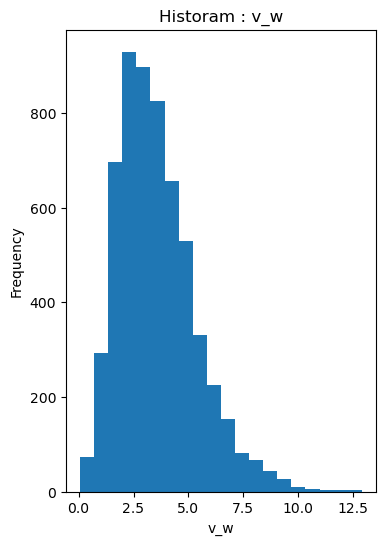

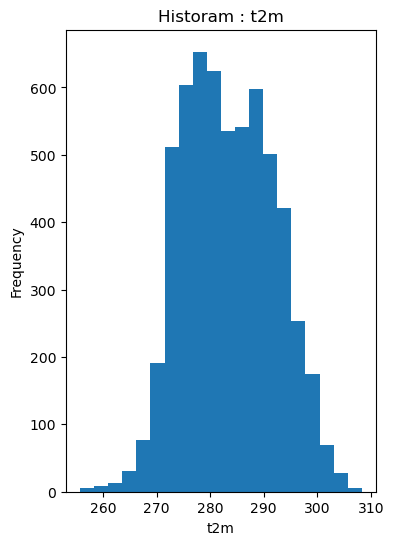

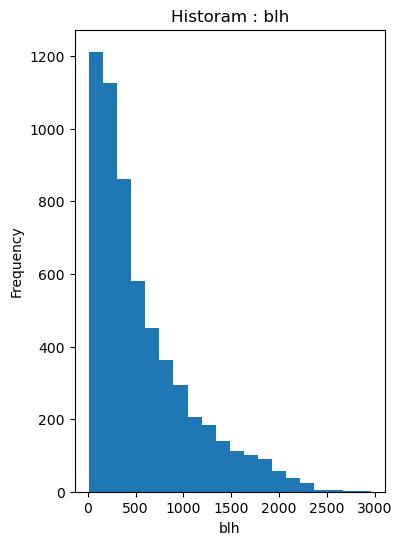

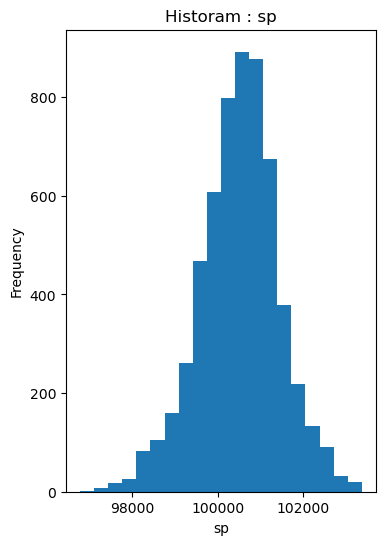

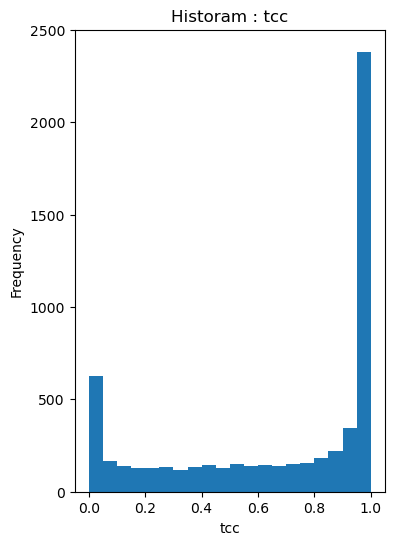

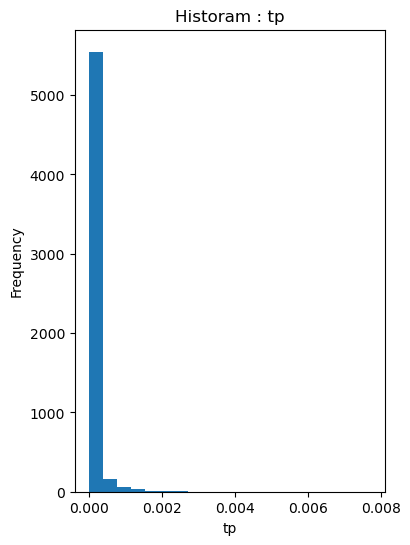

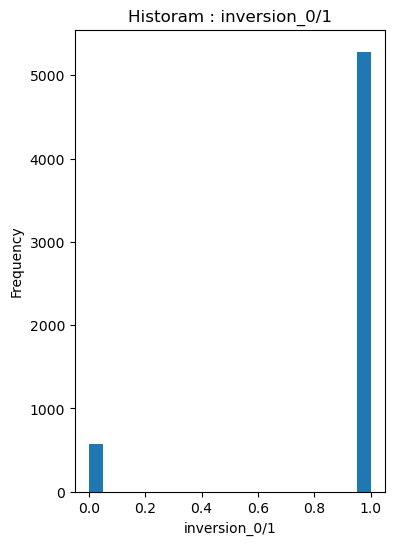

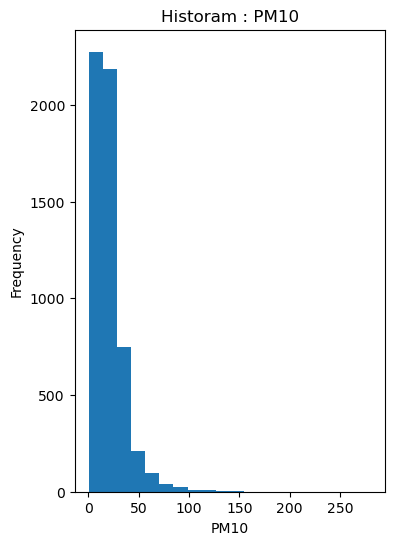

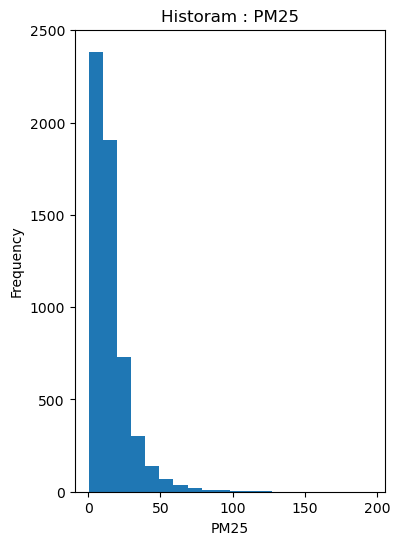

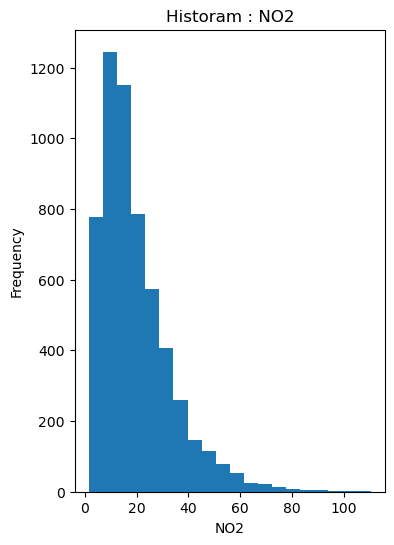

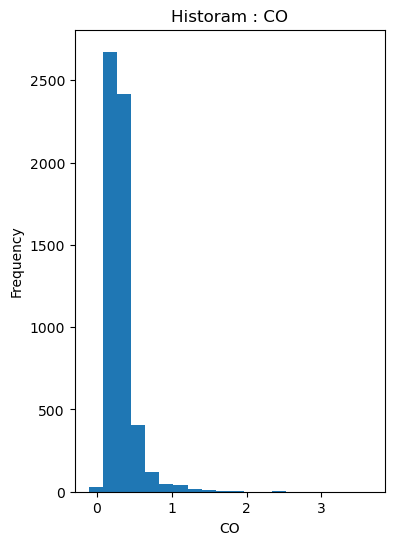

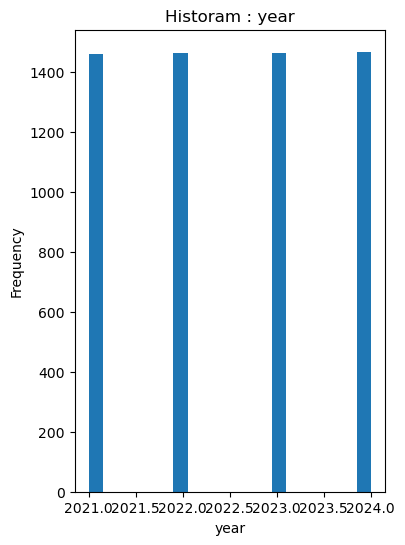

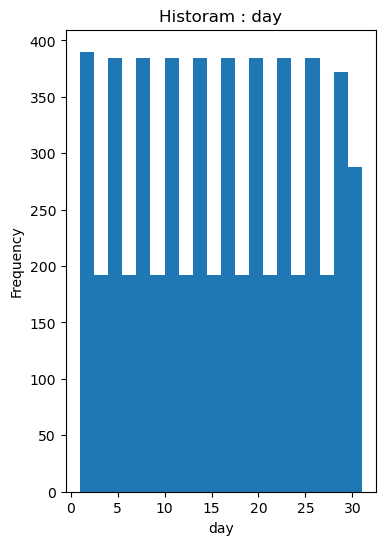

In [382]:
for c in num_col:
    plt.figure(figsize = (4,6))
    plt.hist(pz_main_df[c], bins = 20)
    plt.title(f'Historam : {c}')
    plt.xlabel(c)
    plt.ylabel('Frequency')
    plt.show()
    

#### 2.3.3. Analiza Outliery

Wnioski:

Nie usuwam żadnych outlierów, gdyż sa to dane realne , zdobyte zgodnie ze wskazaniami prawidłowo działjacych stacji meteorologicznych.
Każda wartosć będaca poza zakresem IQR to rzeczywiska obserwacja, więc usunięcie ich byłoby fałszowaniem danych.


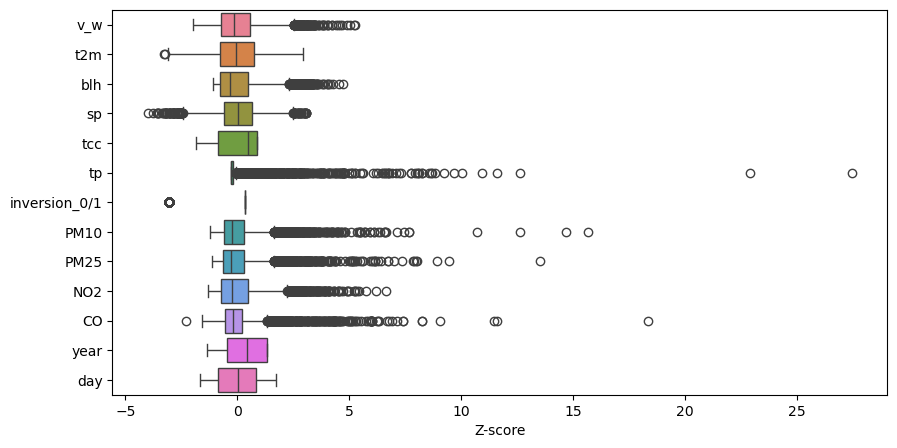

In [384]:
# tworzymy boxplot dla zmiennych z main_df do oceny wizualnej sytuacji outlierów.

num_df = pz_main_df[num_col].copy()

# przy tworzeniu box plot, stosujemy wzrór na Z-sore tj. normalizaja, standaryzacje danych (przeskalownie)
# dla wyraźniejszego pokazania na wykresie rozkładu danych po przez wizualizację statystyk pozycujnych.
plt.figure(figsize=(10,5))
sns.boxplot((num_df-num_df.mean())/num_df.std(),orient='h')
plt.xlabel('Z-score')
plt.show()

#### 2.3.4. Brakujace wartosci.

Dla brakujacych wartości , przed budowa modeli predkcyjnych bedzie trzeba zastosować IMPUTER

In [386]:
df_nan = pz_main_df[num_col].isna().sum().loc[lambda x: x>0].to_frame(name='NaN_count')
df_nan

,NaN_count
tp,6
PM10,239
PM25,239
NO2,176
CO,83


#### 2.3.5. Badanie korelacji cech numerycznych PERSONA

Korelacja Pearsona (r)

Definicja: Mierzy siłę i kierunek liniowej zależności między dwiema zmiennymi ilościowymi.

......................................................................................................................................................................................................................................


Wniosek : Z uwagi na wcześniejsza analiza czynników meteorologicznych majacych wpływ na poziom jakości powietrza na danym obszarze,
postanawiam nie usuwać, żednych z wymienionych cech numerycznych.

Ale w badaniu skuteczności modeli moze okazać się , że niektóre dane wymagaja usuniecia 

In [388]:
corr_matrix = pz_main_df.corr(numeric_only=True,method='pearson')
corr_target = corr_matrix.loc[num_col,target_col]

In [389]:
# g = sns.PairGrid(main_df['bhl'], hue='PM25')

# # Co ma być na przekątnej (np. rozkład)
# g.map_diag(sns.kdeplot, fill=True)

# # Co ma być nad przekątną (np. wykresy punktowe)
# g.map_upper(sns.scatterplot, s=10)

# # Co ma być pod przekątną (np. wykresy gęstości/regresji)
# g.map_lower(sns.kdeplot, levels=4, color=".2")

# plt.show()

In [390]:
# Korelacja ze zmiennymi cech dla PM10

corr_target['PM10'].drop(target_col).abs().sort_values(ascending=False).to_frame()

,PM10
blh,0.298431
inversion_0/1,0.276717
v_w,0.238050
t2m,0.226342
sp,0.159042
year,0.086804
tp,0.057851
tcc,0.033922
day,0.015701


In [391]:
corr_target['PM25'].drop(target_col).abs().sort_values(ascending=False).to_frame()

,PM25
t2m,0.402695
blh,0.367020
inversion_0/1,0.329378
v_w,0.258698
sp,0.165142
year,0.113125
tp,0.052573
tcc,0.030069
day,0.008190


In [392]:
corr_target['NO2'].drop(target_col).abs().sort_values(ascending=False).to_frame()

,NO2
blh,0.430484
year,0.318598
v_w,0.296863
t2m,0.278139
inversion_0/1,0.167135
sp,0.126700
tcc,0.083353
tp,0.063000
day,0.011464


In [393]:
corr_target['CO'].drop(target_col).abs().sort_values(ascending=False).to_frame()

,CO
blh,0.354843
t2m,0.349398
v_w,0.254981
inversion_0/1,0.249141
sp,0.116428
tp,0.045124
tcc,0.027638
day,0.021162
year,0.000502


#### 2.3.5. Badanie korelacji cech kategorycznych i numerycznych.



Cecha,Pearson,Spearman,ϕk​ (Phi_k)
Typ danych,Tylko liczbowe (ciągłe),Liczbowe / Porządkowe,Mieszane (Liczby + Tekst)
Rodzaj relacji,Tylko liniowa,Monotoniczna (niekoniecznie linia),"Dowolna (nawet ""zygzaki"")"
Wrażliwość na outliery,Bardzo wysoka,Niska,Niska
Kierunek (dodatni/ujemny),Tak,Tak,Nie (tylko siła związku)
Wymagany rozkład normalny,Tak,Nie,Nie

In [396]:
# Współczynnik ϕ 2
# Definicja: Nowoczesny współczynnik oparty na teście χ2
# (Chi-kwadrat). Jest rozszerzeniem współczynnika Craméra V.
# Wartości: od 0 do 1 (nie wskazuje kierunku, tylko siłę związku).
# Przykład: Marka samochodu vs Awaryjność. Tutaj nie ma "kolejności" (marki to kategorie), a Pearson ich nie policzy.
# Kiedy najlepsza: W sytuacjach mieszanych (liczby + tekst) oraz gdy zależności są bardzo skomplikowane (np. sinusoida, gdzie Pearson pokaże 0).

corr_phik = main_df.phik_matrix()


interval columns not set, guessing: ['v_w', 't2m', 'blh', 'sp', 'tcc', 'tp', 'inversion_0/1', 'PM10', 'PM25', 'NO2', 'CO', 'year', 'day']


/opt/anaconda3/lib/python3.12/site-packages/phik/data_quality.py:82: UserWarning: Not enough unique value for variable city for analysis 1. Dropping this column
  warnings.warn(


<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:15: SyntaxWarning: invalid escape sequence '\p'
/var/folders/1_/28vylhx11cs54zyvgx55gyfw0000gn/T/ipykernel_11463/55077631.py:15: SyntaxWarning: invalid escape sequence '\p'
  plt.title('Macierz Korelacji $\phi_k$', fontsize=16)


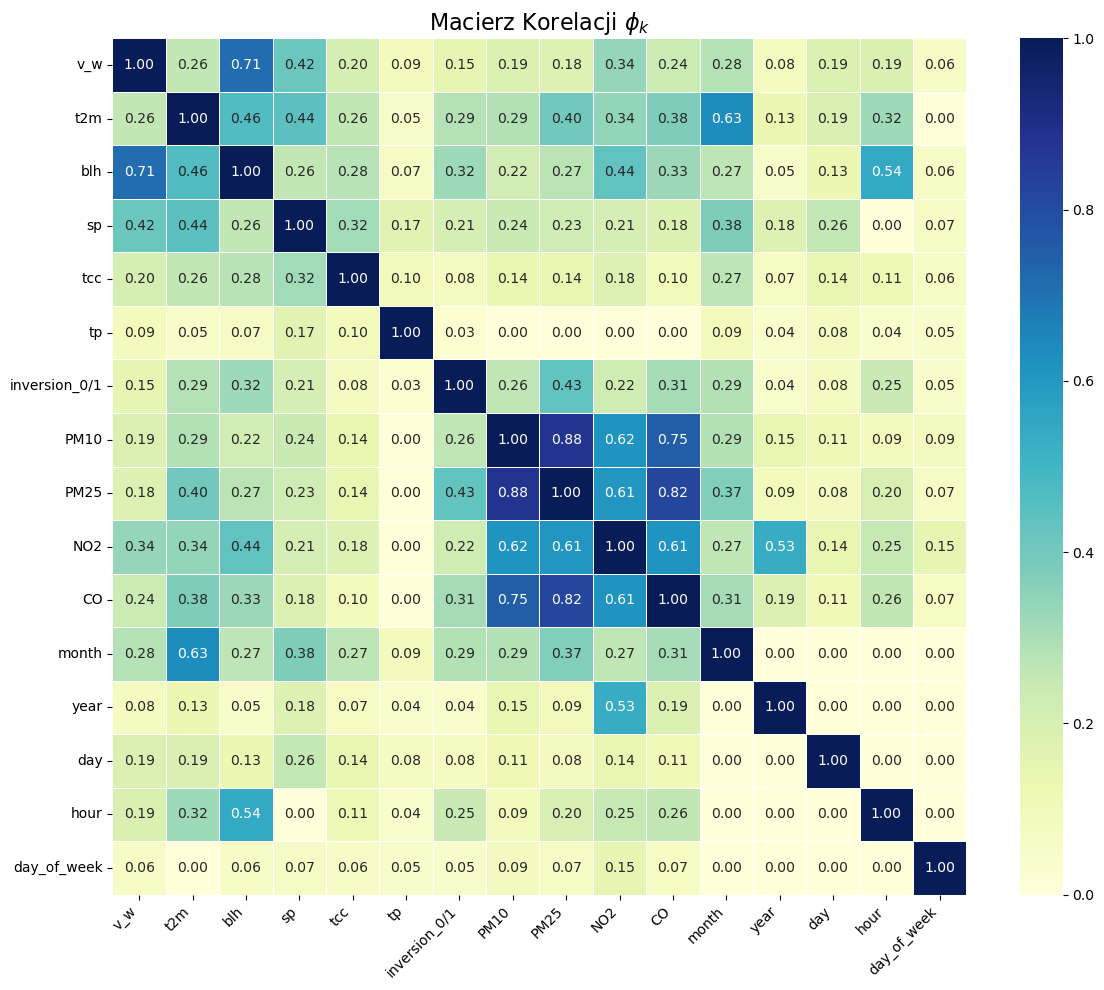

In [397]:
# Wizualizacja macierzy korelacji Phi-kwadrat

plt.figure(figsize = (12,10))
sns.heatmap(
    corr_phik, 
    annot=True,            
    fmt=".2f",            
    cmap='YlGnBu',         
    linewidths=0.5,        
    vmin=0,                
    vmax=1      
)

# 4. Dodanie tytułu i poprawienie czytelności
plt.title('Macierz Korelacji $\phi_k$', fontsize=16)
plt.xticks(rotation=45, ha='right') # Obrócenie nazw kolumn na osi X
plt.tight_layout()

plt.show()

#### 2.3.6. Sprawdzenie duplikatów

##### Wniosek: 
Dane pochodza z profesjonalnego źródła, więc o ile na etapie importu i procesów przygotowania danych nie pojawiły się błędy , to nasz DataFrame nie powienien zawierać żednych duplikatów.

In [400]:
pz_main_df.duplicated().sum()

0

#### 2.3...... Wnioski / Podsumowanie 

<hr style="
height:30px;
border:none;
background: linear-gradient(to right, red, orange, yellow, green, blue, purple);
">

# STEP 3

## 3. Transformacja danych

### 3.1. Walidacja daych celu - target_df

In [406]:
# Uzupełnienie brakujacych wartości NaN na średnia.

target_df = target_df.fillna(target_df.mean())

### 3.1. Preprocessing

In [408]:
# robimy podział na train / test dla całego data setu main_df

X_train, X_test, y_train, y_test = train_test_split(
    feature_df, target_df,
    test_size=0.2,
    random_state=42
) 

#### 3.1.1. Standard Scaller 

In [410]:
# Wyznaczmy kolumny do transdormacji dla Linear Regression 
col_to_scale = [x for x in num_feature_col if x != 'inversion_0/1' and x != 'city' and x != 'time']
# dodanie metody jako zmiennej 
num_scaling = StandardScaler()

In [411]:
col_to_scale

['v_w', 't2m', 'blh', 'year', 'day']

#### 3.1.2. Transformacja Logarytmiczna 

In [413]:
# Wyznaczamy nazwy kolumn dla których zastosowana bedzie Transformacja Logarytmiczna , 
# na podstawie analizy wykonanej w punkcie 2.3.1.
skew_ls = skew_df['features'].to_list()
col_to_logtransform = [x for x in num_feature_col if x in skew_ls and x not in target_col]
# dodanie metody jako zmiennej 
num_logtransform =  FunctionTransformer(np.log1p)

In [414]:
col_to_logtransform

['v_w', 'blh']

In [415]:
X_train

,city,month,hour,day_of_week,v_w,t2m,blh,inversion_0/1,year,day
4862,PZ,April,00:00:00,Monday,3.225748,286.16772,126.196720,1,2024,29
3268,PZ,March,00:00:00,Tuesday,5.259529,273.44580,815.792700,1,2023,28
5718,PZ,November,00:00:00,Friday,4.471759,279.10230,563.697750,1,2024,29
3384,PZ,April,00:00:00,Wednesday,4.563302,277.82422,822.199000,1,2023,26
113,PZ,January,06:00:00,Friday,3.761515,271.25098,661.681400,1,2021,29
...,...,...,...,...,...,...,...,...,...,...
3772,PZ,August,00:00:00,Tuesday,4.170454,292.37988,406.422360,1,2023,1
5191,PZ,July,06:00:00,Saturday,0.552954,294.48413,141.637660,1,2024,20
5226,PZ,July,00:00:00,Monday,4.848294,287.53955,739.836400,1,2024,29
5390,PZ,September,00:00:00,Sunday,4.047171,293.25610,291.136470,1,2024,8


#### 3.1.3. Fill NaN

In [417]:
# Wskazujemy kolumny zawierajace braki NaN. df_nan to odwołanie do widoku z punktu 2.3.3. Brakujace wartosci.
col_to_fillnan = [col for col in df_nan.index.to_list() if col not in target_col]
num_fillNaN = SimpleImputer(strategy='median')

In [418]:
col_to_fillnan

['tp']

#### 3.1.3. One hot encoding

In [420]:
col_to_ohe = cat_feature_col
cat_ohe = OneHotEncoder(handle_unknown='ignore')

In [421]:
col_to_ohe

['city', 'month', 'hour', 'day_of_week']

### 3.2. Pipeline Preprocesing

#### 3.2.1. Linear Regresion Pipeline 

In [424]:
num_311_313_prepro_LR = Pipeline(steps = [
    ('scaliing' , num_scaling),
    ('imputer', num_fillNaN)
])

num_312_prepro_LR  = Pipeline(steps = [
    ('logtrans' , num_logtransform),
    ('imputer', num_fillNaN)
])

cat_313_prepro_LR = Pipeline(steps = [
    ('onehot', cat_ohe)
])

### 3.2. Transformacja

#### 3.2.1. Transformacja Kolumn do Linear Regression

In [427]:
lr_transform = ColumnTransformer(transformers=[
    ('num_scaling+fillNaN', num_311_313_prepro_LR ,col_to_scale),
    ('num_logtrans+fillNaN', num_312_prepro_LR, col_to_scale),
    ('cat_onehot', cat_313_prepro_LR, col_to_ohe)
])

lr_transform2 = ColumnTransformer(transformers=[
    ('cat_onehot', cat_313_prepro_LR, col_to_ohe)
])

## 4. Budowanie Modeli ML

### 4.0. Dummy Regresion 

In [533]:
baseline_dr = DummyRegressor()

models_dr = {}
results_lr = {}

for t in target_col:
    model_dr = baseline_dr.fit(
        X_train, y_train[t],
    )
    preds_dr = model_dr.predict(X_test)
    mae_dr   = mean_absolute_error(y_test[t], preds)
    rmse_dr  = np.sqrt(mean_squared_error(y_test[t], preds))
    r2_dr    = r2_score(y_test[t], preds)

    
    models_lr[t]  = preds_dr
    models_lr[t] = {'MAE': mae_dr, 'RMSE': rmse_dr, 'R2': r2_dr}
    print(f" POLUTION: {t} -> MAE={mae_dr:.3f}  RMSE={rmse_dr:.3f}  R²={r2_dr:.3f}")

 POLUTION: PM10 -> MAE=20.816  RMSE=26.385  R²=-1.626
 POLUTION: PM25 -> MAE=15.439  RMSE=20.392  R²=-1.316
 POLUTION: NO2 -> MAE=19.113  RMSE=23.391  R²=-1.982
 POLUTION: CO -> MAE=0.073  RMSE=0.127  R²=0.492


### 4.1. Linear Regression

#### 4.1.1. Baseline Linear Regression 

In [431]:
baseline_lr = Pipeline([
    ('preprocess', lr_transform),
    ('model', LinearRegression())
])

In [432]:
# MODELOWANIE NA OSOBNYCH TARGETACH POMAGA NA R2


models_lr = {}
results_lr = {}

for t in target_col:
    model_lr = baseline_lr.fit(
        X_train, y_train[t],
    )
    preds = model_lr.predict(X_test)
    mae   = mean_absolute_error(y_test[t], preds)
    rmse  = np.sqrt(mean_squared_error(y_test[t], preds))
    r2    = r2_score(y_test[t], preds)
    
    models_lr[t]  = preds
    models_lr[t] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"  MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.3f}")

  MAE=8.427  RMSE=13.493  R²=0.313
  MAE=6.804  RMSE=10.646  R²=0.369
  MAE=7.183  RMSE=10.063  R²=0.448
  MAE=0.090  RMSE=0.145  R²=0.340


In [433]:
baseline_lr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_scaling+fillNaN', ...), ('num_logtrans+fillNaN', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the out

In [434]:
y_pred_lr = baseline_lr.predict(X_test)

#### 4.1.2. Walidacja Linear Regression

In [536]:
results = {}
for col in target_col:
    y_t = y_test[col]
    y_p = y_pred_lr[:, target_col.index(col)]
    mae  = mean_absolute_error(y_t, y_p)
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    r2   = r2_score(y_t, y_p)
    results[col] = {'MAE': round(mae,3), 'RMSE': round(rmse,3), 'R2': round(r2,3)}

metrics_df = pd.DataFrame(results).T
print(metrics_df)

        MAE    RMSE     R2
PM10  8.427  13.493  0.313
PM25  6.804  10.646  0.369
NO2   7.183  10.063  0.448
CO    0.090   0.145  0.340


In [538]:
# Walidacja skośna (Cross-Validation) 
    # Dzieli Twój zbiór danych na 5 równych części (bo cv=5). Następnie:
    # Trenuje model na 4 częściach, a testuje na 1 (pozostałej).
    # Powtarza to 5 razy, za każdym razem wybierając inną część jako testową
# R2 (współczynnik determinacji) - mowi jaki procent zminności celu został wyjaśniony przez model.

for col in target_col:
    cv_scores = cross_val_score(baseline_lr, feature_df, target_df[col],
                                cv=5, scoring='r2')
    print(f"{col}: CV R² = {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

PM10: CV R² = 0.181 ± 0.103
PM25: CV R² = 0.316 ± 0.056
NO2: CV R² = 0.127 ± 0.201
CO: CV R² = 0.277 ± 0.023


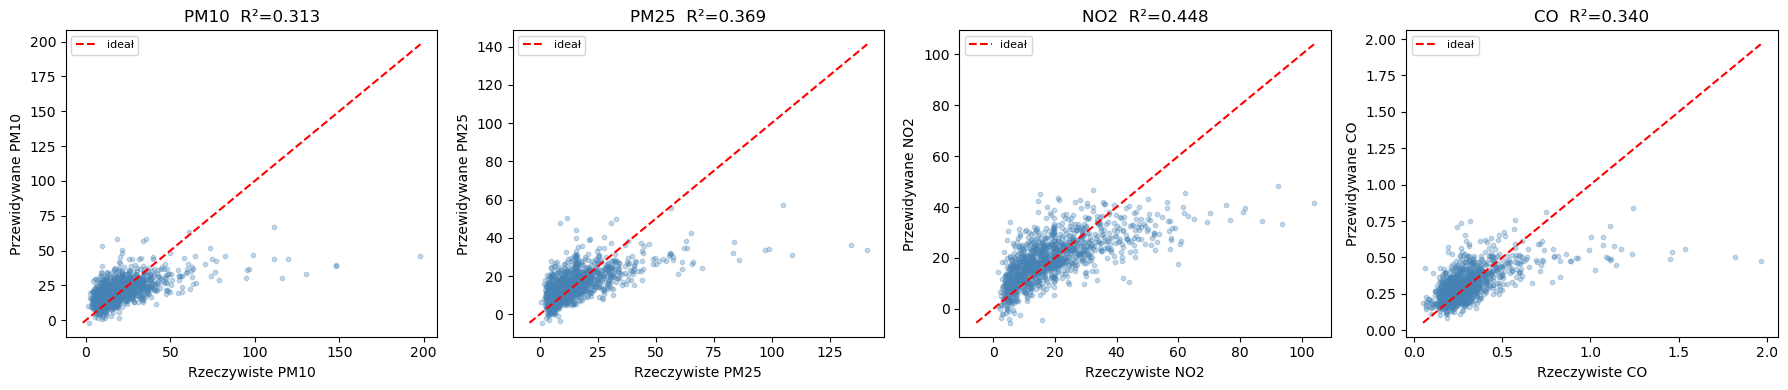

In [540]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, col in enumerate(target_col):
    y_t = y_test[col].values
    y_p = y_pred_lr[:, i]
    axes[i].scatter(y_t, y_p, alpha=0.3, s=10, color='steelblue')
    lim = [min(y_t.min(), y_p.min()), max(y_t.max(), y_p.max())]
    axes[i].plot(lim, lim, 'r--', linewidth=1.5, label='ideał')
    axes[i].set_xlabel(f'Rzeczywiste {col}')
    axes[i].set_ylabel(f'Przewidywane {col}')
    axes[i].set_title(f'{col}  R²={r2_score(y_t,y_p):.3f}')
    axes[i].legend(fontsize=8)
plt.tight_layout()
plt.show()

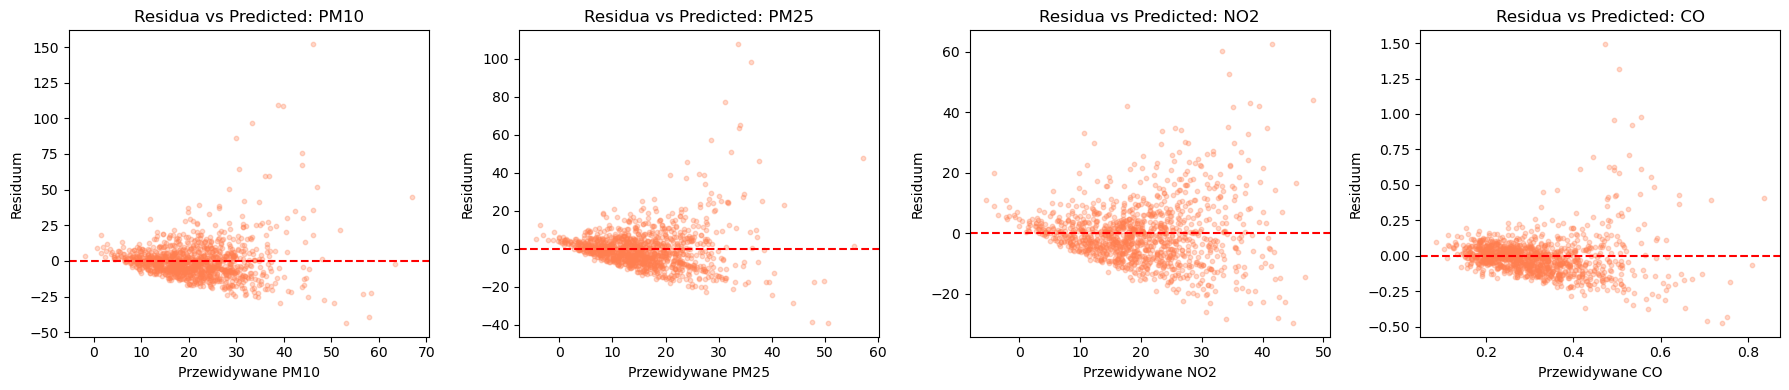

In [542]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, col in enumerate(target_col):
    y_p = y_pred_lr[:, i]
    residuals = y_test[col].values - y_p
    axes[i].scatter(y_p, residuals, alpha=0.3, s=10, color='coral')
    axes[i].axhline(0, color='red', linestyle='--', linewidth=1.5)
    axes[i].set_xlabel(f'Przewidywane {col}')
    axes[i].set_ylabel('Residuum')
    axes[i].set_title(f'Residua vs Predicted: {col}')
plt.tight_layout()
plt.show()

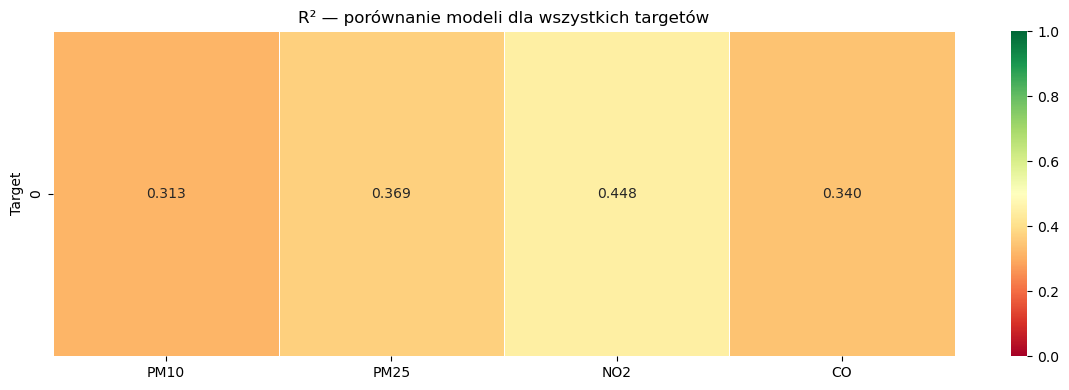

In [544]:
r2_matrix = pd.DataFrame({
    name: df['R2'] for name, df in results.items()
},index=[0])
plt.figure(figsize=(12, 4))
sns.heatmap(r2_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=0.5)
plt.title('R² — porównanie modeli dla wszystkich targetów')
plt.ylabel('Target')
plt.tight_layout()
plt.show()

### 4.2. CatBoost

#### 4.2.1. Baseline_CB 

In [546]:
param_grid = {
    'depth':           [4, 6, 8, 10],
    'learning_rate':   [0.01, 0.03, 0.1],
    'l2_leaf_reg':     [1, 3, 5, 10],
    'iterations':      [300, 500, 800],
    'min_data_in_leaf':[1, 5, 10]
}
models_cb = {}
results_cb = {}

for t in target_col:
    model = CatBoostRegressor(
        iterations          = 800,
        learning_rate       = 0.05,
        depth               = 6,
        l2_leaf_reg         = 3,
        min_data_in_leaf    = 5,
        loss_function       = 'RMSE',
        eval_metric         = 'R2',
        nan_mode            = 'Min',
        random_seed         = 42,
        early_stopping_rounds = 50,
        use_best_model      = True,
        verbose             = 100
    )
    model.fit(
        X_train, y_train[t],
        cat_features = cat_col,
        eval_set     = (X_test, y_test[t])
    )
    preds = model.predict(X_test)
    mae   = mean_absolute_error(y_test[t], preds)
    rmse  = np.sqrt(mean_squared_error(y_test[t], preds))
    r2    = r2_score(y_test[t], preds)
    
    models_cb[t]  = model
    models_cb[t] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"  MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.3f}")

0:	learn: 0.0198492	test: 0.0212642	best: 0.0212642 (0)	total: 16.7ms	remaining: 13.4s
100:	learn: 0.4312390	test: 0.3693819	best: 0.3693819 (100)	total: 468ms	remaining: 3.24s
200:	learn: 0.5104058	test: 0.4004749	best: 0.4008805 (192)	total: 1.19s	remaining: 3.55s
300:	learn: 0.5715922	test: 0.4149372	best: 0.4150105 (299)	total: 2.07s	remaining: 3.43s
400:	learn: 0.6218142	test: 0.4319583	best: 0.4322031 (399)	total: 2.65s	remaining: 2.63s
500:	learn: 0.6628738	test: 0.4489965	best: 0.4489965 (500)	total: 3.18s	remaining: 1.9s
600:	learn: 0.6900212	test: 0.4592224	best: 0.4592454 (599)	total: 3.63s	remaining: 1.2s
700:	learn: 0.7162202	test: 0.4692501	best: 0.4692501 (700)	total: 4.11s	remaining: 580ms
799:	learn: 0.7335381	test: 0.4777452	best: 0.4777452 (799)	total: 4.72s	remaining: 0us

bestTest = 0.4777451986
bestIteration = 799

  MAE=7.127  RMSE=11.766  R²=0.478
0:	learn: 0.0340486	test: 0.0302445	best: 0.0302445 (0)	total: 16.4ms	remaining: 13.1s
100:	learn: 0.5535315	test: 0

## 4.2.2. Walidacja Cat_Boost

# SPRADZENIA 

In [448]:
# X_train.isna().sum()

In [449]:
# (main_df[feature_col]<0).any()

In [450]:
# y_train.isna().sum()

In [451]:
# main_df['inversion_0/1'].unique()
# main_df['inversion_0/1'].isna().sum()

# Możliwe Modele Do sprawdzenia

In [453]:

# # ---- 4.0. Definicja modeli ----
# models = {
#     'LinearRegression' : LinearRegression(),
#     'Ridge'            : Ridge(alpha=1.0),
#     'Lasso'            : Lasso(alpha=0.1, max_iter=5000),
#     'ElasticNet'       : ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000),
#     'RandomForest'     : RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
#     'GradientBoosting' : MultiOutputRegressor(
#                             GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
#                                                       max_depth=4, random_state=42)),
#     'XGBoost'          : MultiOutputRegressor(
#                             XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5,
#                                          subsample=0.8, random_state=42, verbosity=0)),
#     'LightGBM'         : MultiOutputRegressor(
#                             LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=31,
#                                           random_state=42, verbose=-1)),
# }

# # ---- 4.1. Wspólny preprocessing (skalowanie + imputer + log dla LR-based) ----
# # Modele drzewiaste nie potrzebują skalowania — dla nich używamy surowego X
# # Dlatego tworzymy dwa zestawy danych:
# X_train_tree = X_train.copy()   # bez skalowania dla RF/XGB/LGBM
# X_test_tree  = X_test.copy()

# # ---- 4.2. Trening i ewaluacja wszystkich modeli ----
# results_all = {}

# for name, model in models.items():
#     # drzewiaste — bez preprocessingu
#     if name in ['RandomForest', 'GradientBoosting', 'XGBoost', 'LightGBM']:
#         model.fit(X_train_tree, y_train)
#         preds = model.predict(X_test_tree)
#     else:
#         # linearne — używamy pipeline z preprocessingiem
#         pipe = Pipeline([('preprocess', lr_transform), ('model', model)])
#         pipe.fit(X_train, y_train)
#         preds = pipe.predict(X_test)

#     # metryki dla każdego z 4 targetów
#     metrics = {}
#     for i, col in enumerate(target_col):
#         y_t = y_test[col].values
#         y_p = preds[:, i]
#         metrics[col] = {
#             'MAE' : round(mean_absolute_error(y_t, y_p), 3),
#             'RMSE': round(np.sqrt(mean_squared_error(y_t, y_p)), 3),
#             'R2'  : round(r2_score(y_t, y_p), 3)
#         }
#     results_all[name] = pd.DataFrame(metrics).T
#     print(f"\n{name}:\n{results_all[name]}")


# # ---- 4.3. Heatmapa porównawcza R² ----
# r2_matrix = pd.DataFrame({
#     name: df['R2'] for name, df in results_all.items()
# })

# plt.figure(figsize=(14, 4))
# sns.heatmap(r2_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
#             vmin=0, vmax=1, linewidths=0.5, cbar_kws={'label': 'R²'})
# plt.title('R² — porównanie modeli dla wszystkich targetów')
# plt.ylabel('Target')
# plt.tight_layout()
# plt.show()


# # ---- 4.4. Feature importance (RandomForest jako przykład) ----
# rf_model = models['RandomForest']
# importances = pd.Series(rf_model.feature_importances_,
#                         index=X_train_tree.columns).sort_values(ascending=False)

# plt.figure(figsize=(10, 5))
# importances[:15].plot(kind='bar', color='steelblue', edgecolor='white')
# plt.title('Feature importance — RandomForest (top 15)')
# plt.ylabel('Importance')
# plt.tight_layout()
# plt.show()


# # ---- 4.5. Strojenie hiperparametrów — przykład dla XGBoost / PM10 ----
# from sklearn.model_selection import RandomizedSearchCV

# param_grid = {
#     'estimator__n_estimators'     : [100, 200, 300, 500],
#     'estimator__max_depth'        : [3, 4, 5, 6, 8],
#     'estimator__learning_rate'    : [0.01, 0.05, 0.1],
#     'estimator__subsample'        : [0.6, 0.7, 0.8, 1.0],
#     'estimator__colsample_bytree' : [0.6, 0.8, 1.0],
# }

# xgb_search = RandomizedSearchCV(
#     estimator  = MultiOutputRegressor(XGBRegressor(random_state=42, verbosity=0)),
#     param_distributions = param_grid,
#     n_iter     = 30,
#     cv         = 5,
#     scoring    = 'r2',
#     random_state = 42,
#     n_jobs     = -1,
#     verbose    = 1
# )
# xgb_search.fit(X_train_tree, y_train)

# print("Najlepsze parametry XGBoost:", xgb_search.best_params_)
# print("Najlepszy R² CV:", round(xgb_search.best_score_, 3))